In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/10010
1


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  1 , total integrated cost =  9283.02945648727
RUN  2 , total integrated cost =  9240.06771950335
RUN  3 , total integrated cost =  9238.640167662206
RUN  4 , total integrated cost =  9238.592381420476
RUN  5 , total integrated cost =  9238.582115125417
RUN  6 , total integrated cost =  9238.57333460646
RUN  7 , total integrated cost =  9238.565317470013
RUN  8 , total integrated cost =  9238.55731688274
RUN  9 , total integrated cost =  9238.552229986562
RUN  10 , total integrated cost =  9238.548566027937
RUN  11 , total integrated cost =  9238.545673944629
RUN  12 , total integrated cost =  9238.543806768284
RUN  13 , total integrated cost =  9238.540987937426
RUN  14 , total integrated cost =  9238.537274408569
RUN  15 , total integrated cost =  9238.536506520115
RUN  16 , tota

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1029 , total integrated cost =  9237.987017434583
Improved over  1029  iterations in  50.093108747154474  seconds by  30.6011224002944  percent.
Problem in initial value trasfer:  Vmean_exc -56.64425713410017 -56.64459622271064
weight =  14.409454944905942
set cost params:  1.0 0.0 14.409454944905942
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9358.069853904333
Gradient descend method:  None
RUN  1 , total integrated cost =  9358.069853904333
Control only changes marginally.
RUN  1 , total integrated cost =  9358.069853904333
Improved over  1  iterations in  0.1186662595719099  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64425713410017 -56.64459622271064
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  1 , total integrated cost =  180

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  37 , total integrated cost =  17981.107363022857
Improved over  37  iterations in  1.428279371932149  seconds by  16.61971115521746  percent.
Problem in initial value trasfer:  Vmean_exc -56.689290963357486 -56.68955699764926
weight =  11.993242214134813
set cost params:  1.0 0.0 11.993242214134813
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18024.001873614467
Gradient descend method:  None
RUN  1 , total integrated cost =  18024.001873614467
Control only changes marginally.
RUN  1 , total integrated cost =  18024.001873614467
Improved over  1  iterations in  0.11774607747793198  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.689290963357486 -56.68955699764926
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21069.13235378212
Gradient descend method:  None
RUN  1 , total integrated cost =  1

...

RUN  190 , total integrated cost =  9095.802026855883
Control only changes marginally.
RUN  195 , total integrated cost =  9095.80202669525
Improved over  195  iterations in  5.125159025192261  seconds by  10.098978311506315  percent.
Problem in initial value trasfer:  Vmean_exc -56.64443789377356 -56.64462804942058
weight =  11.12334410909135
set cost params:  1.0 0.0 11.12334410909135
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9109.711973129086
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  9109.711973129086
Control only changes marginally.
RUN  1 , total integrated cost =  9109.711973129086
Improved over  1  iterations in  0.07114662416279316  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64443789377356 -56.64462804942058
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23430.768838654094
Gradient descend method:  None
RUN  1 , total integrated cost =  22624.717676849756
RUN  2 , total integrated cost =  22515.216315126672
RUN  3 , total integrated cost =  22514.94823944198
RUN  4 , total integrated cost =  22514.91962384215
RUN  5 , total integrated cost =  22514.8938452313
RUN  6 , total integrated cost =  22514.882653473407
RUN  7 , total integrated cost =  22514.855681322904
RUN  8 , total integrated cost =  22514.815567098547
RUN  9 , total integrated cost =  22514.75202512644
RUN  10 , total integrat

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  140 , total integrated cost =  22491.277593959283
Control only changes marginally.
RUN  140 , total integrated cost =  22491.277593959283
Improved over  140  iterations in  4.200680810958147  seconds by  4.009647532969211  percent.
Problem in initial value trasfer:  Vmean_exc -56.699093108425735 -56.69914598932123
weight =  10.417713596201908
set cost params:  1.0 0.0 10.417713596201908
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22495.822701868816
Gradient descend method:  None
RUN  1 , total integrated cost =  22495.822701868816
Control only changes marginally.
RUN  1 , total integrated cost =  22495.822701868816
Improved over  1  iterations in  0.12202824652194977  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.699093108425735 -56.69914598932123


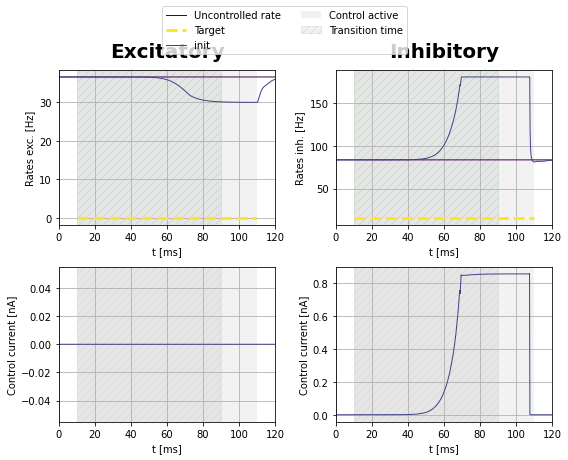

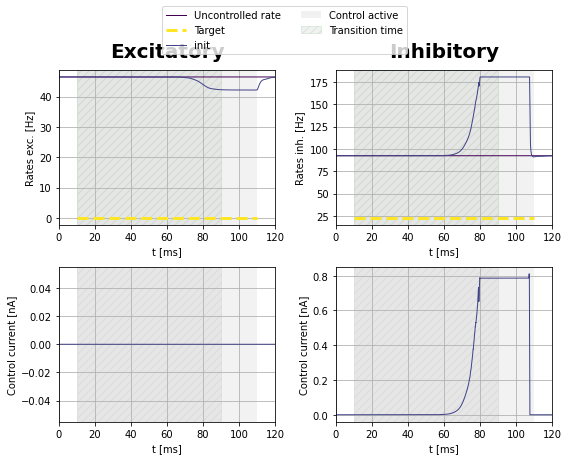

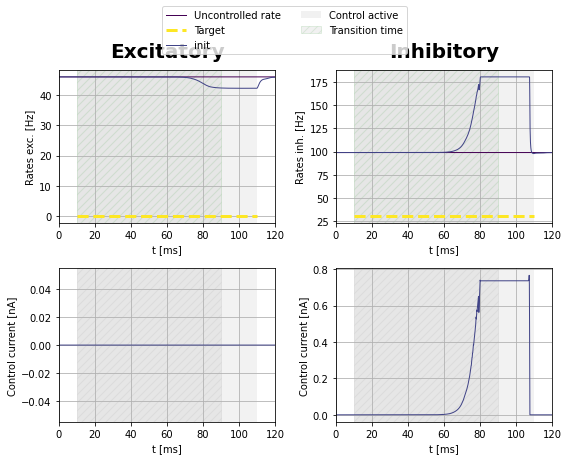

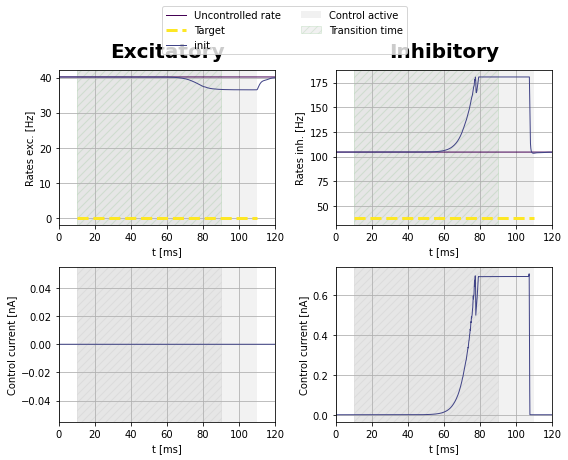

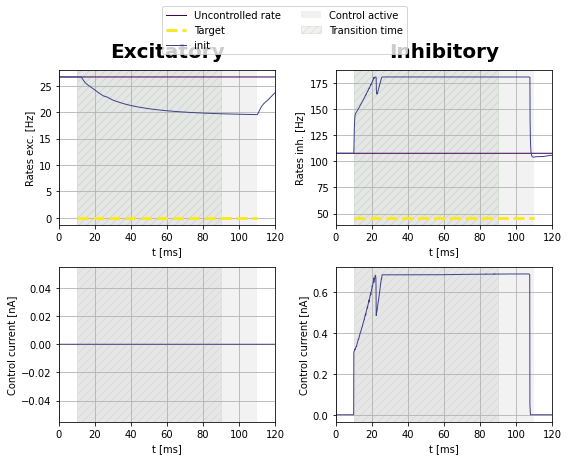

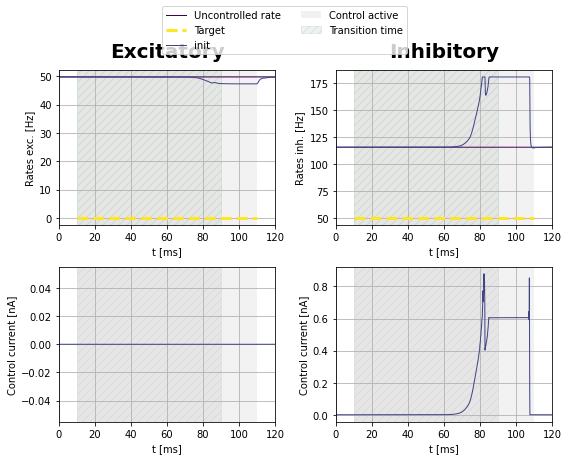

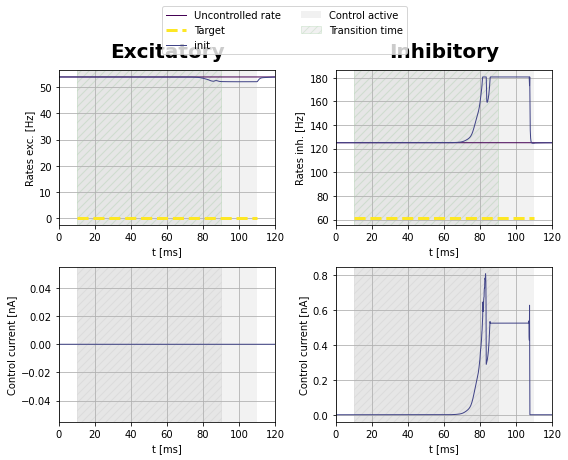

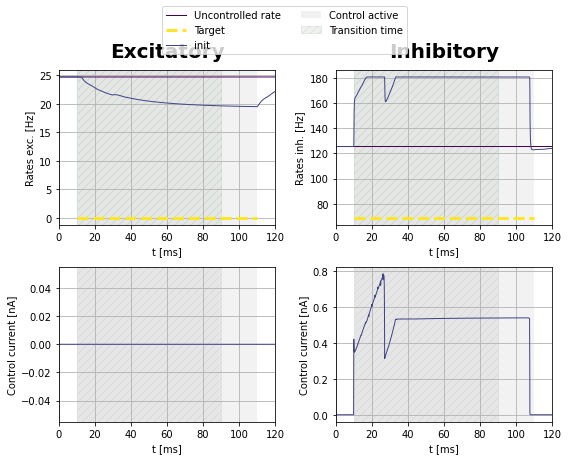

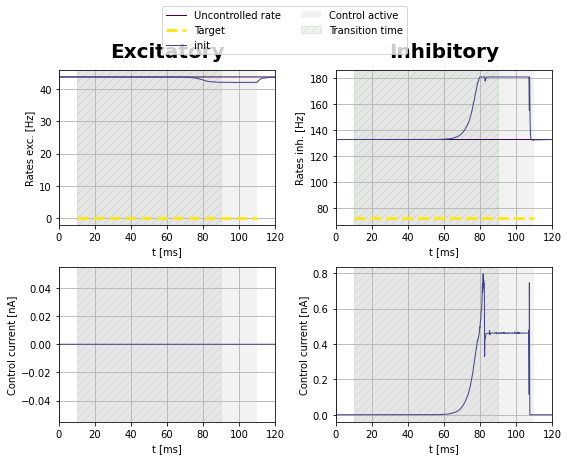

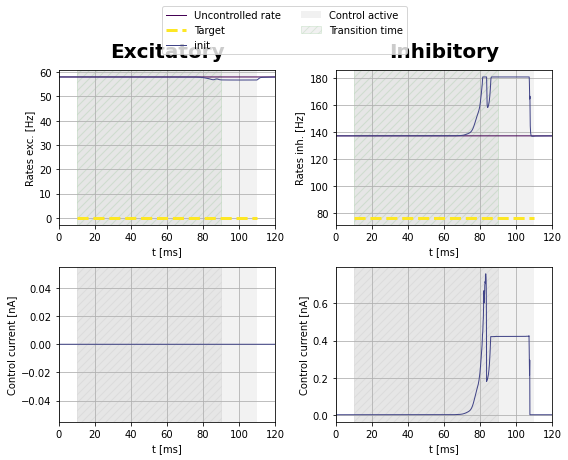

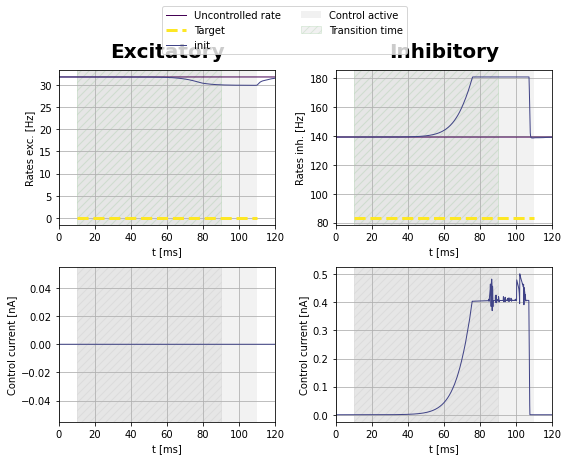

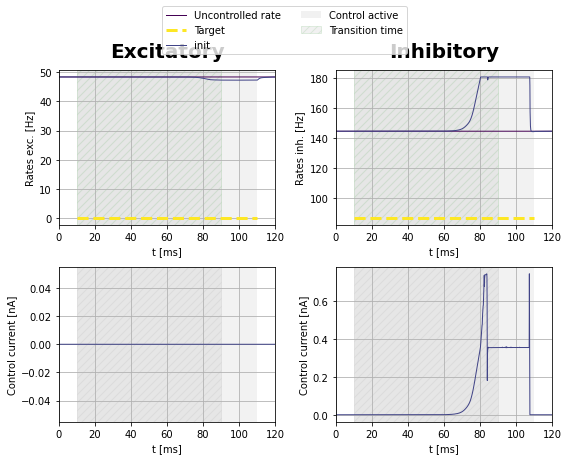

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  Tru

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  2000 , total integrated cost =  9245.14102178112
RUN  2000 , total integrated cost =  9245.14102178112
Improved over  2000  iterations in  67.19315214641392  seconds by  27.60708408479698  percent.
Problem in initial value trasfer:  Vmean_exc -56.644704837221454 -56.645158564128145
weight =  14.3983047306405
set cost params:  1.0 0.0 14.3983047306405
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9357.60153056452
Gradient descend method:  None
RUN  1 , total integrated cost =  9357.60153056452
Control only changes marginally.
RUN  1 , total integrated cost =  9357.60153056452
Improved over  1  iterations in  0.12322098016738892  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.644704837221454 -56.645158564128145
-------  22 0.5000000000000002 0.4750000000000002
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21177.32966146453
Gradi

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  22 , total integrated cost =  17981.517768412235
Improved over  22  iterations in  0.964931096881628  seconds by  15.090721748868901  percent.
Problem in initial value trasfer:  Vmean_exc -56.68929278085877 -56.68955953883958
weight =  11.992968483557439
set cost params:  1.0 0.0 11.992968483557439
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  18024.05619532314
Gradient descend method:  None
RUN  1 , total integrated cost =  18024.05619532314
Control only changes marginally.
RUN  1 , total integrated cost =  18024.05619532314
Improved over  1  iterations in  0.12407027184963226  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68929278085877 -56.68955953883958
-------  33 0.5000000000000002 0.5250000000000002
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20750.294661411455
Gradient descend method

...

RUN  11 , total integrated cost =  32300.785484457385
Control only changes marginally.
RUN  11 , total integrated cost =  32300.785484457385
Improved over  11  iterations in  0.4912105482071638  seconds by  3.6812300122732893  percent.
Problem in initial value trasfer:  Vmean_exc -56.703837753030115 -56.703840783783
weight =  10.412272525443102
set cost params:  1.0 0.0 10.412272525443102
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  32305.301008007118
Gradient descend method:  None
RUN  1 , total integrated cost =  32305.301008007118
Control only changes marginally.
RUN  1 , total integrated cost =  32305.301008007118
Improved over  1  iterations in  0.12062550522387028  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703837753030115 -56.703840783783
-------  132 0.4500000000000001 0.8750000000000006
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total inte

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  148 , total integrated cost =  9100.778268630007
Improved over  148  iterations in  5.28765314258635  seconds by  8.901902719292778  percent.
Problem in initial value trasfer:  Vmean_exc -56.64435599484941 -56.64454287792266
weight =  11.117261942294563
set cost params:  1.0 0.0 11.117261942294563
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9116.279449180181
Gradient descend method:  None
RUN  1 , total integrated cost =  9116.279449180181
Control only changes marginally.
RUN  1 , total integrated cost =  9116.279449180181
Improved over  1  iterations in  0.11950244195759296  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64435599484941 -56.64454287792266
-------  143 0.5250000000000001 0.9000000000000006
[0] []
closest index  0
set cost params:  1.0 0.0 10.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23362.924120366544
Gradient descend method

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  36 , total integrated cost =  22488.87799853326
Improved over  36  iterations in  1.4311883319169283  seconds by  3.741167489695087  percent.
Problem in initial value trasfer:  Vmean_exc -56.699091516776775 -56.69914354555306
weight =  10.418825181132766
set cost params:  1.0 0.0 10.418825181132766
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22493.144612470835
Gradient descend method:  None
RUN  1 , total integrated cost =  22493.144612470835
Control only changes marginally.
RUN  1 , total integrated cost =  22493.144612470835
Improved over  1  iterations in  0.12213250808417797  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.699091516776775 -56.69914354555306
------------------------------------------------------------
-------------------- 1
------------------------------------------------------------
found solution:  [0]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-----

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
no convergence
weight =  13.16331752323768
set cost params:  1.0 0.0 13.16331752323768
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13602.863808257562
Gradient descend method:  None
RUN  1 , total integrated cost =  13602.863808257562
Control only changes marginally.
RUN  1 , total integrated cost =  13602.863808257562
Improved over  1  iterations in  0.11989441141486168  seconds by  0.0  percent.
Problem in initial value 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  9222.28654298204
Control only changes marginally.
RUN  1 , total integrated cost =  9222.28654298204
Improved over  1  iterations in  0.12197592668235302  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.64439796075096 -56.64466831514184
-------  88 0.5500000000000003 0.7250000000000004
no convergence
weight =  10.353612311104616
set cost params:  1.0 0.0 10.353612311104616
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  27334.825539975605
Gradient descend method:  None
RUN  1 , total integrated cost =  27334.825539975605
Control only changes marginally.
RUN  1 , total integrated cost =  27334.825539975605
Improved over  1  iterations in  0.12100608088076115  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70352037107527 -56.70356784893763
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9245.14102178112
Gradient descend method:  None
RUN  1 , total integrated cost =  318.6244747654506
RUN  2 , total integrated cost =  63.410049260806375
RUN  3 , total integrated cost =  46.68046202711582
RUN  4 , total integrated cost =  43.3176178592434
RUN  5 , total integrated cost =  40.29062886116382
RUN  6 , total integrated cost =  37.065101995912435
RUN  7 , total integrated cost =  34.4080074666397
RUN  8 , total integrated cost =  30.45404954791618
RUN  9 , total integrated cost =  30.398728185225877
RUN  10 , total integrated cost =  29.985127984185695
RUN  11 , total integrated cost =  29.7750923332873
RUN  12 , total integrated cost =  29.73142607444066
RUN  13 , total integrated cost =  29.53289250430903
RUN  14 , total integrated cost =  29.455196353114236
RUN  15 , total integrated cost =  29.412906289795966
RUN  16 ,

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  75 , total integrated cost =  25.518555279927533
Improved over  75  iterations in  11.698010843247175  seconds by  99.72397873412848  percent.
Problem in initial value trasfer:  Vmean_exc -65.78616071488872 -65.79230225887348
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  251.36702668015317
Gradient descend method:  HS
RUN  1 , total integrated cost =  245.97052003556178
RUN  2 , total integrated cost =  244.6706413481432
RUN  3 , total integrated cost =  243.18989804133471
RUN  4 , total integrated cost =  243.1673759827417
RUN  5 , total integrated cost =  242.915418276969
RUN  6 , total integrated cost =  242.87610348832115
RUN  7 , total integrated cost =  242.8344147051564
RUN  8 , total integrated cost =  242.8343689298359
RUN  9 , total integrated cost =  242.83337605063846
RUN  10 , total integrated cost =  242.83334363750095
RUN  11 , total integrated cost =  242.827793

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  242.82779360536543
Control only changes marginally.
RUN  13 , total integrated cost =  242.82779360536543
Improved over  13  iterations in  2.430554822087288  seconds by  3.3971174292694  percent.
Problem in initial value trasfer:  Vmean_exc -65.00716462139864 -65.02346700256078
weight =  5480.841914920254
set cost params:  1.0 0.0 5480.841914920254
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13128.485019932228
Gradient descend method:  None
RUN  1 , total integrated cost =  12748.051669949416
RUN  2 , total integrated cost =  12747.71573488713
RUN  3 , total integrated cost =  12747.599880615002
RUN  4 , total integrated cost =  12734.985380246873
RUN  5 , total integrated cost =  12725.52290668779
RUN  6 , total integrated cost =  12725.516771765928
RUN  7 , total integrated cost =  12725.51626325454
RUN  8 , total integrated cost =  12725.51605279675
RUN  9 , total integrated cost =  12725.515991950051
RUN  10 , total in

...

Control only changes marginally.
RUN  44 , total integrated cost =  42.57375897640271
Improved over  44  iterations in  4.105106201022863  seconds by  99.81068971524867  percent.
Problem in initial value trasfer:  Vmean_exc -67.08727954125528 -67.11823749398401
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  416.04649336813014
Gradient descend method:  HS
RUN  1 , total integrated cost =  403.5774828941941
RUN  2 , total integrated cost =  401.8850003474136
RUN  3 , total integrated cost =  401.8395426643511
RUN  4 , total integrated cost =  401.8373153074888
RUN  5 , total integrated cost =  401.83731530748855


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  401.83731530748855
Control only changes marginally.
RUN  6 , total integrated cost =  401.83731530748855
Improved over  6  iterations in  1.742413379251957  seconds by  3.415286100745689  percent.
Problem in initial value trasfer:  Vmean_exc -64.23762116254065 -64.27329098856606
weight =  5829.909163009094
set cost params:  1.0 0.0 5829.909163009094
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  22894.977877209287
Gradient descend method:  None
RUN  1 , total integrated cost =  21947.260853722633
RUN  2 , total integrated cost =  21945.535726066708
RUN  3 , total integrated cost =  21918.089309014882
RUN  4 , total integrated cost =  21899.616763025828
RUN  5 , total integrated cost =  21899.58331077357
RUN  6 , total integrated cost =  21899.53920494952
RUN  7 , total integrated cost =  21890.845542074556
RUN  8 , total integrated cost =  21885.964681188798
RUN  9 , total integrated cost =  21885.964681188783


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  21885.964681188776
RUN  11 , total integrated cost =  21885.964681188776
Control only changes marginally.
RUN  11 , total integrated cost =  21885.964681188776
Improved over  11  iterations in  2.842855781316757  seconds by  4.407137676358843  percent.
Problem in initial value trasfer:  Vmean_exc -57.21322637891885 -57.20160803967222


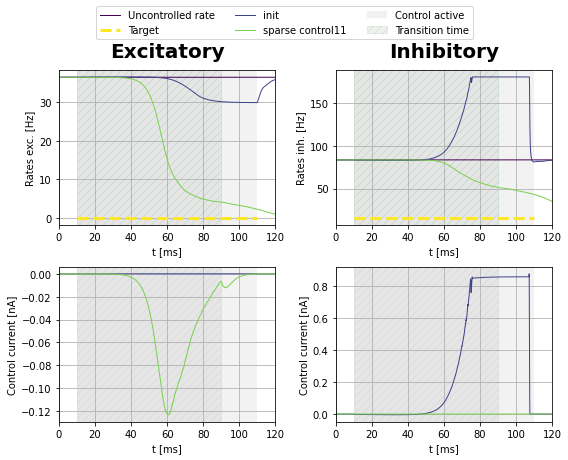

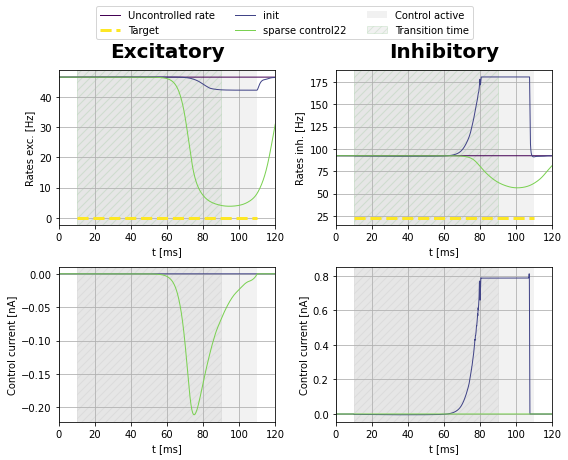

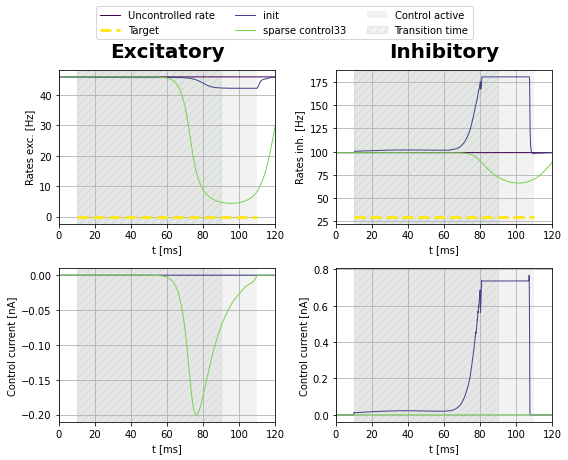

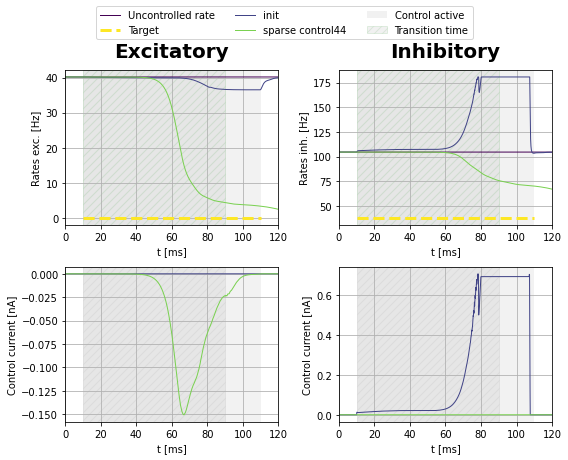

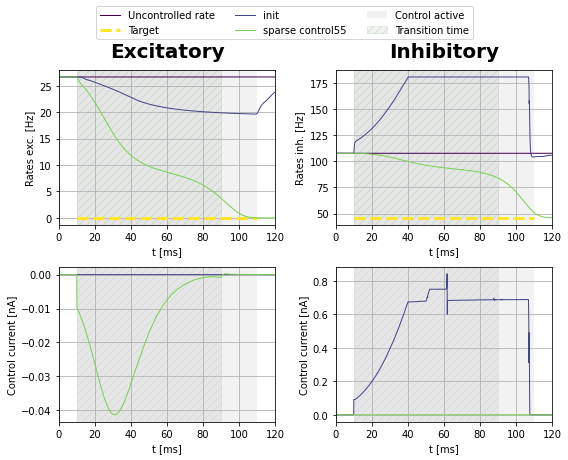

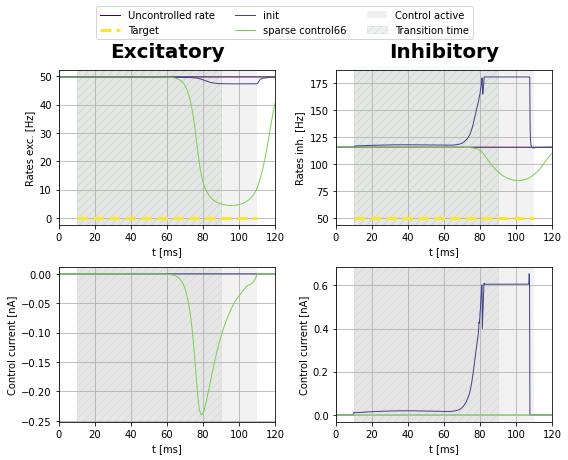

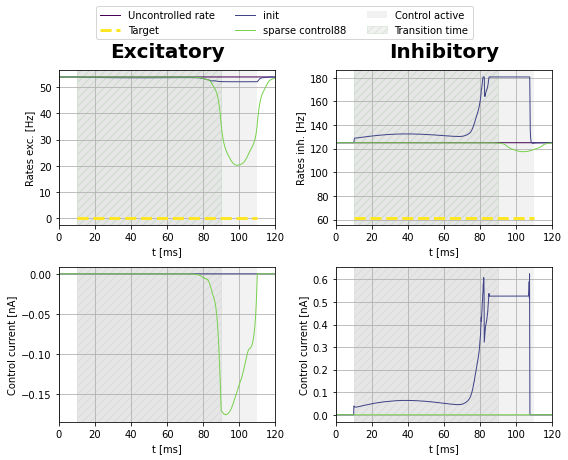

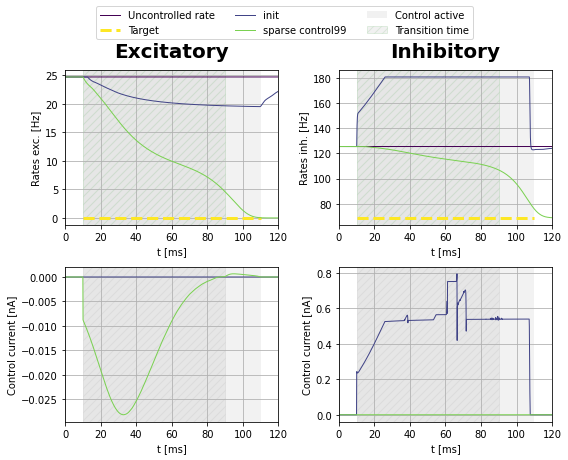

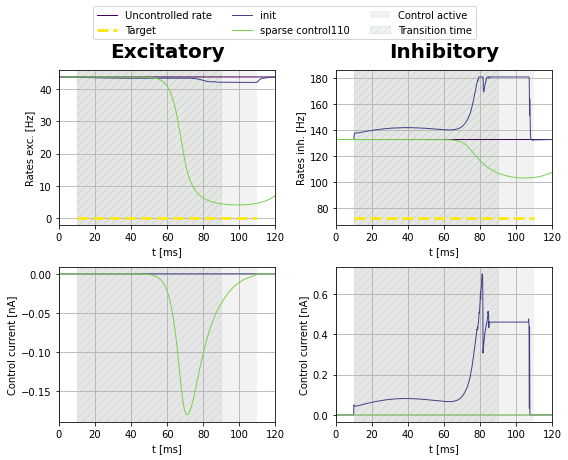

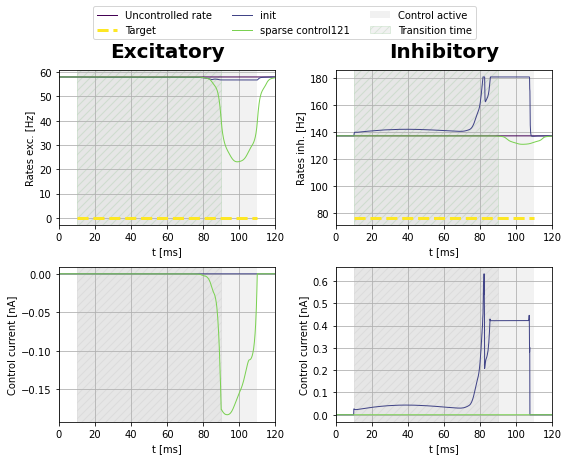

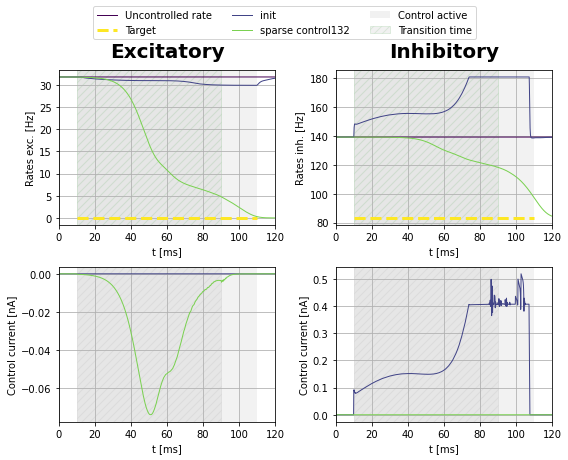

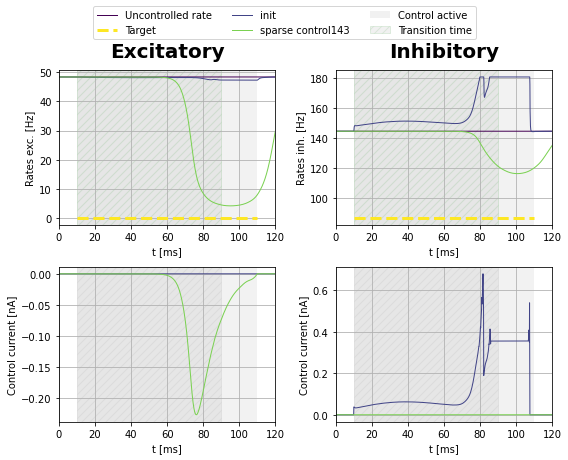

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  5732.195822592475
set cost params:  1.0 0.0 5732.195822592475
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13304.233832948574
Gradient descend method:  None
RUN  1 , total integrated cost =  13304.186338896752
RUN  2 , total integrated cost =  13304.183503349792
RUN  3 , total integrated cost =  13304.183222023003
RUN  4 , total integrated cost =  13304.18319999754
RUN  5 , total integrated cost =  13304.183190383063
RUN  6 , total integrated cost =  13304.183190253749
RUN  7 , total integrated cost =  13304.18319025374


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  13304.18319025374
Control only changes marginally.
RUN  8 , total integrated cost =  13304.18319025374
Improved over  8  iterations in  2.1735268235206604  seconds by  0.00038065096772754714  percent.
Problem in initial value trasfer:  Vmean_exc -59.01678994938585 -59.02567141992277
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  5985.011074633324
set cost params:  1.0 0.0 5985.011074633324
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21545.417491898363
Gradient descend method:  None
RUN  1 , total integrated cost =  21544.91495971608
RUN  2 , total integrated cost =  21544.90952080893
RUN  3 , total integrated cost =  21544.909424258385
RUN  4 , total integrated cost =  21544.90942092467
RUN  5 , total integrated cost =  21544.909420474207
RUN  6 , total integrated cost =  21544.909420400338
RUN  7 , total integrated cost =  21544.90942039006
RUN  8 , total integrated cost =  21544.909420388634
RUN

ERROR:root:Problem in initial value trasfer


RUN  13 , total integrated cost =  21544.909420388383
Control only changes marginally.
RUN  13 , total integrated cost =  21544.909420388383
Improved over  13  iterations in  3.4602425638586283  seconds by  0.002358141865528296  percent.
Problem in initial value trasfer:  Vmean_exc -57.13237035371345 -57.12029294722835
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  6023.049531483831
set cost params:  1.0 0.0 6023.049531483831
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21043.87999832387
Gradient descend method:  None
RUN  1 , total integrated cost =  21043.260717845053
RUN  2 , total integrated cost =  21043.25565483568
RUN  3 , total integrated cost =  21043.255541683637
RUN  4 , total integrated cost =  21043.25554168362
RUN  5 , total integrated cost =  21043.25554168361


...

RUN  2 , total integrated cost =  33627.64260426313
Control only changes marginally.
RUN  2 , total integrated cost =  33627.64260426313
Improved over  2  iterations in  0.6713068038225174  seconds by  5.572755412686092e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.70370247679629 -56.70367920343335
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 99
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
c

ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  33627.674689938955
Control only changes marginally.
RUN  3 , total integrated cost =  33627.674689938955
Improved over  3  iterations in  0.9948134813457727  seconds by  8.033219955905224e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.70370173043682 -56.70367852427145
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 100
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.625000000000000

ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  33627.70562096295
Control only changes marginally.
RUN  4 , total integrated cost =  33627.70562096295
Improved over  4  iterations in  1.2803193666040897  seconds by  5.020356752538646e-08  percent.
Problem in initial value trasfer:  Vmean_exc -56.703701382197764 -56.70367820738822
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 101


In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  112.67224941350712
Gradient descend method:  None
RUN  1 , total integrated cost =  4.513372068324604
RUN  2 , total integrated cost =  4.4832198000574905
RUN  3 , total integrated cost =  4.483217866412497
RUN  4 , total integrated cost =  4.483217866412485
RUN  5 , total integrated cost =  4.483217866412482
RUN  6 , total integrated cost =  4.4832178664124775


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  4.4832178664124775
Control only changes marginally.
RUN  7 , total integrated cost =  4.4832178664124775
Improved over  7  iterations in  0.4164755046367645  seconds by  96.02100970758197  percent.
Problem in initial value trasfer:  Vmean_exc -66.01389881255119 -66.01854467105397
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  258.8597555382998
Gradient descend method:  None
RUN  1 , total integrated cost =  12.71180235418854
RUN  2 , total integrated cost =  12.56515397098211
RUN  3 , total integrated cost =  12.510544272733938
RUN  4 , total integrated cost =  12.470995569702943
RUN  5 , total integrated cost =  12.470995569702916
RUN  6 , total integrated cost =  12.470995569702914


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  12.470995569702914
Control only changes marginally.
RUN  7 , total integrated cost =  12.470995569702914
Improved over  7  iterations in  0.470174977555871  seconds by  95.18233510505739  percent.
Problem in initial value trasfer:  Vmean_exc -64.73882812970201 -64.7467151080337
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  297.9410538820461
Gradient descend method:  None
RUN  1 , total integrated cost =  16.68360113097259
RUN  2 , total integrated cost =  16.432900646183988
RUN  3 , total integrated cost =  16.404972248460528
RUN  4 , total integrated cost =  16.404972248460517
RUN  5 , total integrated cost =  16.404972248460513


...

Control only changes marginally.
RUN  23 , total integrated cost =  31078.605931396498
Improved over  23  iterations in  0.9454139992594719  seconds by  4.3811137349484  percent.
Problem in initial value trasfer:  Vmean_exc -56.70399473602526 -56.703996464642564
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  80.18210284528065
Gradient descend method:  None
RUN  1 , total integrated cost =  4.870149536061623
RUN  2 , total integrated cost =  4.848909880694639
RUN  3 , total integrated cost =  4.848909880694614


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  4.848909880694612
RUN  5 , total integrated cost =  4.848909880694612
Control only changes marginally.
RUN  5 , total integrated cost =  4.848909880694612
Improved over  5  iterations in  0.3661714009940624  seconds by  93.95262819428537  percent.
Problem in initial value trasfer:  Vmean_exc -71.69392535193971 -71.73786612259231
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  271.780545243136
Gradient descend method:  None
RUN  1 , total integrated cost =  37.77839030269636
RUN  2 , total integrated cost =  35.17439412945881
RUN  3 , total integrated cost =  34.45862035844497
RUN  4 , total integrated cost =  34.18393258611161
RUN  5 , total integrated cost =  34.03669766395706
RUN  6 , total integrated cost =  33.96316046017208
RUN  7 , total integrated cost =  33.92783103595357
RUN  8 , total integrated cost =  33.89912158388398
RUN  9 , total int

ERROR:root:Problem in initial value trasfer


RUN  90 , total integrated cost =  33.81877190450857
Control only changes marginally.
RUN  90 , total integrated cost =  33.81877190450857
Improved over  90  iterations in  3.5029888097196817  seconds by  87.55658839588604  percent.
Problem in initial value trasfer:  Vmean_exc -63.36678180563864 -63.39951822841829


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.4832178664124775
Gradient descend method:  None
RUN  1 , total integrated cost =  4.4832178664124775
Control only changes marginally.
RUN  1 , total integrated cost =  4.4832178664124775
Improved over  1  iterations in  0.0642577838152647  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -66.01389881255119 -66.01854467105397
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  12.470995569702914
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  12.470995569702914
Control only changes marginally.
RUN  1 , total integrated cost =  12.470995569702914
Improved over  1  iterations in  0.06797251850366592  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -64.73882812970201 -64.7467151080337
-------  33 0.5000000000000002 0.5250000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  16.404972248460513
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  31078.605931396498
Control only changes marginally.
RUN  1 , total integrated cost =  31078.605931396498
Improved over  1  iterations in  0.11789928190410137  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70399473602526 -56.703996464642564
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  4.848909880694612
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  4.848909880694612
Control only changes marginally.
RUN  1 , total integrated cost =  4.848909880694612
Improved over  1  iterations in  0.11417032033205032  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.69392535193971 -71.73786612259231
-------  143 0.5250000000000001 0.9000000000000006
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33.81877190450857
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33.81877190450857
Control only changes marginally.
RUN  1 , total integrated cost =  33.81877190450857
Improved over  1  iterations in  0.11641477607190609  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -63.36678180563864 -63.39951822841829
--------------- 12
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004


In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
